# Three-Dimensional Interpolation of Tangential Vector Fields

This notebook demonstrates polynomial interpolation of tangential vector fields on convex polytopes in 3D.
It uses **pyvista** for interactive 3D visualization.

In [2]:
from pathlib import Path
import sys

import numpy as np
import pyvista as pv
from scipy.spatial import ConvexHull, Delaunay

from sage.all import QQ, diff, matrix, vector

ROOT = Path.cwd()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from hyperplane_arrangements import *

# Use static images for notebook rendering (change to 'client' for interactive)
pv.global_theme.jupyter_backend = 'static'
pv.global_theme.background = 'white'
pv.global_theme.font.color = 'black'

print(f'Repository root: {ROOT}')

Repository root: /Users/kaji/Library/CloudStorage/Dropbox/maple/HyperplaneArrangement


## Shared 3D Helpers

In [7]:
def sample_points_in_polyhedron(vertices, n, seed=None):
    """Uniformly sample *n* points inside a 3-D convex polyhedron."""
    verts = np.asarray(vertices, dtype=float)
    rng = np.random.default_rng(int(seed))
    tri = Delaunay(verts)
    lo, hi = verts.min(0), verts.max(0)
    out = []
    while len(out) < n:
        batch = rng.uniform(lo, hi, size=(max(4 * n, 1024), 3))
        out.extend(batch[tri.find_simplex(batch) >= 0])
    return np.array(out[:n], dtype=float)


def evaluate_3d_field(A, vf, pt):
    g = A.S.gens()
    subs = {g[i]: float(pt[i]) for i in range(3)}
    if len(g) > 3:
        subs[g[3]] = 1
    return np.array([float(c.subs(subs)) for c in vf[:3]], dtype=float)


def evaluate_3d_field_batch(A, vf, points):
    return np.array([evaluate_3d_field(A, vf, p)
                     for p in np.atleast_2d(points)])


def boundary_samples_3d(vertices, per_face=200, seed=None):
    """Sample points on each triangular boundary face with outward normals."""
    verts = np.asarray(vertices, dtype=float)
    hull = ConvexHull(verts)
    rng = np.random.default_rng(int(seed))
    all_p, all_n, all_f = [], [], []
    for fi, (simp, eq) in enumerate(zip(hull.simplices, hull.equations)):
        n = eq[:3] / np.linalg.norm(eq[:3])
        v0, v1, v2 = verts[simp]
        r = rng.random((per_face, 2))
        over = r.sum(1) > 1
        r[over] = 1 - r[over]
        pts = (np.outer(1 - r[:, 0] - r[:, 1], v0)
               + np.outer(r[:, 0], v1) + np.outer(r[:, 1], v2))
        all_p.append(pts)
        all_n.append(np.tile(n, (per_face, 1)))
        all_f.append(np.full(per_face, fi))
    return np.vstack(all_p), np.vstack(all_n), np.concatenate(all_f)


def unconstrained_basis_3d(A, degree):
    """All polynomial vector fields up to *degree* (no tangential constraint)."""
    v = A.S.gens()[:-1]
    zero = A.S.zero()
    G = []
    for d in range(degree + 1):
        for a in range(d + 1):
            for b in range(d - a + 1):
                c = d - a - b
                p = v[0]**a * v[1]**b * v[2]**c
                G.append(vector([p, zero, zero]))
                G.append(vector([zero, p, zero]))
                G.append(vector([zero, zero, p]))
    return G

def pv_tetrahedron_mesh(vertices):
    """Create a pyvista mesh for a tetrahedron."""
    verts = np.asarray(vertices, dtype=float)
    hull = ConvexHull(verts)
    faces = []
    for simplex in hull.simplices:
        faces.extend([3, *simplex])
    return pv.PolyData(verts, faces=faces)


def add_arrows(plotter, origins, vectors, color='viridis', scale=1.0,
               scalar_name='speed', opacity=0.7, clim=None):
    """Add a quiver (arrow glyph) layer to a pyvista plotter."""
    origins = np.asarray(origins, dtype=float)
    vectors = np.asarray(vectors, dtype=float)
    speed = np.linalg.norm(vectors, axis=1)
    cloud = pv.PolyData(origins)
    cloud['vectors'] = vectors * scale
    cloud[scalar_name] = speed
    arrows = cloud.glyph(orient='vectors', scale='vectors', factor=1.0)
    if isinstance(color, str) and color in ['viridis', 'plasma', 'coolwarm', 'RdBu_r']:
        plotter.add_mesh(arrows, scalars=scalar_name, cmap=color, opacity=opacity,
                         clim=clim, show_scalar_bar=False)
    else:
        plotter.add_mesh(arrows, color=color, opacity=opacity, show_scalar_bar=False)


def add_observation_arrows(plotter, obs_dict, scale=1.0):
    """Overlay observation arrows in red + red stars for singular points."""
    pts = np.array(list(obs_dict.keys()), dtype=float)
    vecs = np.array(list(obs_dict.values()), dtype=float)
    speed_sq = (vecs ** 2).sum(axis=1)

    # Non-singular observations: red arrows
    nonzero = speed_sq > 1e-10
    if nonzero.any():
        add_arrows(plotter, pts[nonzero], vecs[nonzero],
                   color='red', scale=scale, opacity=1.0)

    # Singular points: red stars
    singular = ~nonzero
    if singular.any():
        sing_cloud = pv.PolyData(pts[singular])
        plotter.add_mesh(sing_cloud, color='red', point_size=100*scale,
                         render_points_as_spheres=True, opacity=.5)
        # # Add a slightly larger transparent sphere for visibility
        # plotter.add_mesh(sing_cloud, color='red', point_size=28,
        #                  render_points_as_spheres=True, opacity=0.5)


print('PyVista visualization helpers loaded.')

print('3-D helpers loaded.')

PyVista visualization helpers loaded.
3-D helpers loaded.


## 1. Interpolation on a Tetrahedron

The standard 3-simplex $\{x \ge 0,\; y \ge 0,\; z \ge 0,\; x+y+z \le 1\}$ gives
a hyperplane arrangement with 5 hyperplanes (4 faces + the hyperplane at infinity).
We prescribe up to 6 interior velocity observations (including singular points where the velocity is zero)
and fit tangential fields of degree 2 and 3.

In [3]:
tet_vertices = [(0, 0, 0), (1, 0, 0), (0, 1, 0), (0, 0, 1)]

A_tet = HyperplaneArrangement(vertices=tet_vertices)
tet_gens = A_tet.minimal_generators()[1:]

print(f'Tetrahedron:  n = {A_tet.n},  hyperplanes = {A_tet.num_planes}')
print(f'  generator degrees (excl. Euler) = {tet_gens.degs()},  free = {A_tet.is_free}')

# Observations including singular points (zero velocity)
tet_obs = {
    (0.15, 0.05, 0.75): ( 1.0,  0.5, -0.3),
    (0.50, 0.15, 0.10): ( 0.0,  1.0,  0.5),
    (0.10, 0.30, 0.30): ( 0.0,  0.0,  0.0),   # singular point
    (0.10, 0.50, 0.15): (-0.5,  0.0,  1.0),
    (0.30, 0.30, 0.10): ( 0.3,  0.4, -1.0),
    (0.10, 0.10, 0.50): ( 0.0,  0.0,  0.0),   # singular point
}

scenarios_tet = [(2, 3), (2, 6), (3, 3), (3, 6)]

for deg, nobs in scenarios_tet:
    Obs = dict(list(tet_obs.items())[:nobs])
    mod = tet_gens.graded_component(deg)
    vf, res = fit_vf(A_tet, Obs, mod, verbose=False)
    print(f'  deg {deg},  {nobs} obs:  dim = {len(mod)},  residual = {res:.4e}')

Tetrahedron:  n = 4,  hyperplanes = 5
  generator degrees (excl. Euler) = [2, 2, 2, 2, 2, 2],  free = False
  deg 2,  3 obs:  dim = 6,  residual = 5.8820e-01
  deg 2,  6 obs:  dim = 6,  residual = 3.3344e+00
  deg 3,  3 obs:  dim = 20,  residual = 1.6771e-29
  deg 3,  6 obs:  dim = 20,  residual = 3.6213e-26


In [ ]:
eval_pts_tet = sample_points_in_polyhedron(tet_vertices, 1000, seed=42)
tet_mesh = pv_tetrahedron_mesh(tet_vertices)

plotter = pv.Plotter(shape=(2, 2), window_size=(1600, 1200))

for idx, (deg, nobs) in enumerate(scenarios_tet):
    row, col = divmod(idx, 2)
    plotter.subplot(row, col)

    Obs = dict(list(tet_obs.items())[:nobs])
    mod = tet_gens.graded_component(deg)
    vf, res = fit_vf(A_tet, Obs, mod, verbose=False)

    # Evaluate interpolated field
    vecs = evaluate_3d_field_batch(A_tet, vf, eval_pts_tet)
    spd = np.linalg.norm(vecs, axis=1)
    mx = max(spd.max(), 1e-10)
    arrow_scale = 0.17 / mx

    # Interpolated field: viridis arrows
    add_arrows(plotter, eval_pts_tet, vecs, color='viridis',
               scale=arrow_scale, opacity=0.5, clim=[0, mx])

    # Observation arrows overlaid in red (same scale)
    add_observation_arrows(plotter, Obs, scale=0.15)

    # Tetrahedron: wireframe only (no solid face)
    plotter.add_mesh(tet_mesh, style='wireframe', color='black', line_width=2)

    plotter.add_text(f'Degree {deg}, {nobs} obs\nresidual = {res:.2e}',
                     position='upper_left', font_size=10, color='black')
    plotter.camera_position = 'iso'

plotter.show()

## 2  Reconstruction on a Cube
For the unit cube $[0,1]^3$, the arrangement has 6 face hyperplanes plus the
hyperplane at infinity (7 total).  We synthesise a degree-4 tangential ground
truth, perturb 80 observations with 2 % noise, and compare an unconstrained
polynomial fit against the tangential fit.

**Figures produced:**
1. 3-D quiver plots of the ground truth, unconstrained, and tangential fits.
2. Cross-sections at $z = 0.5$ for a clearer 2-D comparison.
3. Per-face boundary leakage $|\xi \cdot n|$ (bar chart).

In [8]:
cube_vertices = [
    (0, 0, 0), (1, 0, 0), (0, 1, 0), (0, 0, 1),
    (1, 1, 0), (1, 0, 1), (0, 1, 1), (1, 1, 1),
]

A_cube = HyperplaneArrangement(vertices=cube_vertices)
cube_gens = A_cube.minimal_generators()[1:]

print(f'Cube:  n = {A_cube.n},  hyperplanes = {A_cube.num_planes}')
print(f'  generator degrees (excl. Euler) = {cube_gens.degs()},  free = {A_cube.is_free}')

# --- synthetic ground truth: random tangential field of degree 4 ---
gt_deg = 4
gt_mod = cube_gens.graded_component(gt_deg)
gt_aff = gt_mod.affine_basis()
n_basis = len(gt_aff)
print(f'  tangential basis dim at degree {gt_deg}: {n_basis}')

rng0 = np.random.default_rng(int(42))
gt_coeffs = rng0.normal(size=n_basis)
gt_mat = matrix([g.v for g in gt_aff.gens])
vf_gt = VectorField(gt_mat.transpose() * vector(gt_coeffs.tolist()))

# rescale to unit RMS
scale_pts = sample_points_in_polyhedron(cube_vertices, 2000, seed=7)
rms = float(np.sqrt(np.mean(evaluate_3d_field_batch(A_cube, vf_gt, scale_pts) ** 2)))
if rms > 0:
    vf_gt = VectorField(vf_gt.v / rms)
print(f'  ground truth rescaled to unit RMS')

# --- noisy observations ---
n_obs = 80
obs_pts = sample_points_in_polyhedron(cube_vertices, n_obs, seed=100)
obs_true = evaluate_3d_field_batch(A_cube, vf_gt, obs_pts)
rng1 = np.random.default_rng(int(200))
obs_noisy = obs_true + rng1.normal(scale=0.02, size=obs_true.shape)
Obs_cube = {tuple(p): tuple(v) for p, v in zip(obs_pts, obs_noisy)}

# --- fit: tangential vs unconstrained ---
fit_deg = 4
tgt_mod = cube_gens.graded_component(fit_deg)
G_unc = unconstrained_basis_3d(A_cube, fit_deg)
print(f'  tangential dim = {len(tgt_mod)},  unconstrained dim = {len(G_unc)}')

vf_tgt, res_tgt = fit_vf(A_cube, Obs_cube, tgt_mod, verbose=False)
vf_unc, res_unc = fit_vf(A_cube, Obs_cube, G_unc, verbose=False)

# --- error metrics ---
test_pts = sample_points_in_polyhedron(cube_vertices, 2000, seed=999)
gt_v = evaluate_3d_field_batch(A_cube, vf_gt, test_pts)
tgt_v = evaluate_3d_field_batch(A_cube, vf_tgt, test_pts)
unc_v = evaluate_3d_field_batch(A_cube, vf_unc, test_pts)
tgt_rmse = float(np.sqrt(np.mean((tgt_v - gt_v) ** 2)))
unc_rmse = float(np.sqrt(np.mean((unc_v - gt_v) ** 2)))

# boundary leakage
bpts, bnorms, bfids = boundary_samples_3d(cube_vertices, per_face=300, seed=77)
tgt_leak = np.abs(np.sum(evaluate_3d_field_batch(A_cube, vf_tgt, bpts) * bnorms, 1))
unc_leak = np.abs(np.sum(evaluate_3d_field_batch(A_cube, vf_unc, bpts) * bnorms, 1))

print(f'\n  Tangential    — RMSE = {tgt_rmse:.4f},  mean |ξ·n| = {tgt_leak.mean():.4e}')
print(f'  Unconstrained — RMSE = {unc_rmse:.4f},  mean |ξ·n| = {unc_leak.mean():.4f}')

Cube:  n = 4,  hyperplanes = 7
  generator degrees (excl. Euler) = [2, 2, 2],  free = True
  tangential basis dim at degree 4: 30
  ground truth rescaled to unit RMS
  tangential dim = 30,  unconstrained dim = 105

  Tangential    — RMSE = 0.0078,  mean |ξ·n| = 1.4192e-16
  Unconstrained — RMSE = 0.0286,  mean |ξ·n| = 0.0368


In [9]:
# ---------- PyVista: 3-D quiver comparison ----------

vis_pts = sample_points_in_polyhedron(cube_vertices, 350, seed=55)
cube_mesh = pv.Box(bounds=(0, 1, 0, 1, 0, 1))

panels = [
    ('Ground truth', vf_gt),
    (f'Unconstrained  (RMSE={unc_rmse:.3f})', vf_unc),
    (f'Tangential  (RMSE={tgt_rmse:.3f})', vf_tgt),
]

plotter = pv.Plotter(shape=(1, 3), window_size=(1800, 600))

for idx, (title, vf) in enumerate(panels):
    plotter.subplot(0, idx)
    vecs = evaluate_3d_field_batch(A_cube, vf, vis_pts)
    spd = np.linalg.norm(vecs, axis=1)
    mx = max(spd.max(), 1e-10)
    sc = 0.06 / mx

    add_arrows(plotter, vis_pts, vecs, color='viridis',
               scale=sc, opacity=0.7, clim=[0, mx])

    # Show observations on ground truth panel
    if idx == 0:
        obs_dict_cube = {tuple(p): tuple(v) for p, v in zip(obs_pts, obs_noisy)}
        add_observation_arrows(plotter, obs_dict_cube, scale=sc)

    # Wireframe only (no solid face)
    plotter.add_mesh(cube_mesh, style='wireframe', color='black', line_width=1.5)
    plotter.add_text(title, position='upper_left', font_size=10, color='black')
    plotter.camera_position = 'iso'

plotter.show()

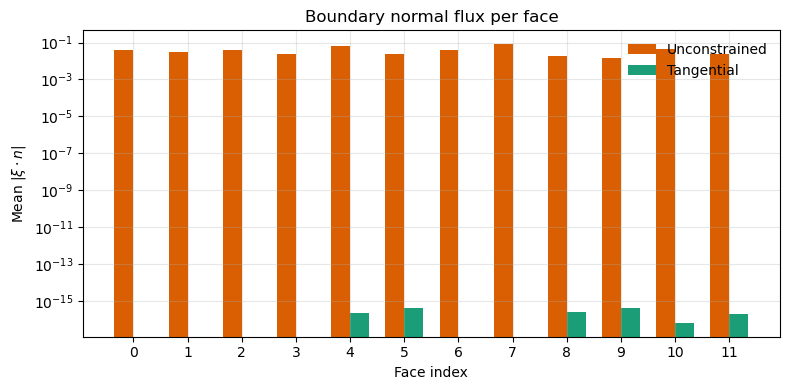

In [10]:
import matplotlib.pyplot as plt

# ---------- Boundary leakage per face ----------
n_faces = len(np.unique(bfids))
face_idx = np.arange(n_faces)
unc_mean_f = [float(np.mean(unc_leak[bfids == i])) for i in face_idx]
tgt_mean_f = [float(np.mean(tgt_leak[bfids == i])) for i in face_idx]

fig, ax = plt.subplots(figsize=(8, 4))
w = 0.35
ax.bar(face_idx - w / 2, unc_mean_f, w, label='Unconstrained', color='#d95f02')
ax.bar(face_idx + w / 2, tgt_mean_f, w, label='Tangential', color='#1b9e77')
ax.set_yscale('log')
ax.set_xlabel('Face index')
ax.set_ylabel(r'Mean $|\xi \cdot n|$')
ax.set_title('Boundary normal flux per face')
ax.set_xticks(face_idx)
ax.legend(frameon=False)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()